In [1]:
import requests
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sci
from scipy.stats import binned_statistic_2d
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

In [2]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"e7205be31fb9f9b069960f52cf1481c1"}

In [3]:
h=0.6774
sn,scales,zs=np.loadtxt("redshifts.dat",unpack=True)

In [4]:
def factors(snap):
   a=scales[snap]
   aa=np.sqrt(a)
   redshift=zs[snap]
   scalefactor=1./(1+redshift)
   kpc=scalefactor/h
   return aa, kpc

In [5]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [6]:
def download(subid,snapnum,nameid):
    aa,kpc=factors(snapnum)

    url = "http://www.tng-project.org/api/TNG50-1/snapshots/"+str(snapnum)+"/subhalos/"+str(subid)
    sub=get(url)

    if sub['len_stars']>0:
       cutout_stars={'stars':'Coordinates,Masses,Velocities,GFM_StellarFormationTime,ParticleIDs'}    
       stars=get(url+"/cutout.hdf5",cutout_stars)    
       with h5py.File(stars,'r+') as f:
           x = f['PartType4']['Coordinates'][:,0] - sub['pos_x']
           y = f['PartType4']['Coordinates'][:,1] - sub['pos_y']
           z = f['PartType4']['Coordinates'][:,2] - sub['pos_z']
           masses=f['PartType4']['Masses'][:]
           vx = aa*f['PartType4']['Velocities'][:,0] - sub['vel_x']
           vy = aa*f['PartType4']['Velocities'][:,1] - sub['vel_y']
           vz = aa*f['PartType4']['Velocities'][:,2] - sub['vel_z']
           t=f['PartType4']['GFM_StellarFormationTime'][:]
       outdat=np.transpose((masses/h,x*kpc,y*kpc,z*kpc,vx,vy,vz,t))
       np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt', outdat)
       return outdat

In [7]:
filename = 'stellar_circs.hdf5'
f = h5py.File(filename, 'r')

disks=[]



for i in range((len(f['Snapshot_99']['MassTensorEigenVals']))): #len(f['Snapshot_99']['MassTensorEigenVals']) total number of tensors(disks)

    m1=f['Snapshot_99']['MassTensorEigenVals'][i][0]
    m2=f['Snapshot_99']['MassTensorEigenVals'][i][1]
    m3=f['Snapshot_99']['MassTensorEigenVals'][i][2]
    #print(m1,m2,m3)
    flatness=m1/np.sqrt(m2*m3)
    if flatness<0.7:
       disks.append(f['Snapshot_99']['SubfindID'][i]) #id of the disks with the criteria

print(len(disks)/len(f['Snapshot_99']['MassTensorEigenVals'])) #nomber of disks with flatness<0.7/ total number of disks

np.savetxt('disk_ax.dat',disks)

0.510501012145749


In [8]:
filename = 'stellar_circs.hdf5'
f = h5py.File(filename, 'r')

disks=[]

for i in range(len(f['Snapshot_99']['CircAbove07Frac'])): # len(f['Snapshot_99']['CircAbove07Frac']) total number of disks with epsilon>0.7
     if f['Snapshot_99']['CircAbove07Frac'][i]>0.2:
          disks.append(f['Snapshot_99']['SubfindID'][i])  #id of the disks with the criteria
print(len(disks)/len(f['Snapshot_99']['CircAbove07Frac'])) #nomber of disks with >0.2/ total number of disks with epsilon>0.7

np.savetxt('disk_circ.dat',disks)

0.45736336032388664


In [9]:
h=0.6774
sim="TNG50-1"

mass_min = (10**10.8) / 1e10 * h
mass_max = 2*(10**12) / 1e10 * h

stars_min= 10**10 / 1e10 * h
stars_max= 15*(10**10) / 1e10 *h

search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)


url = "http://www.tng-project.org/api/"+sim+"/snapshots/99/subhalos/" + search_query
subhalos = get(url,{'limit':5000} )


print(len(subhalos['results'])) #number of subhalos with the criteria
totdm=subhalos['count']         #number of subhalos with the criteria

dm_stars=[]

i=0
while i<totdm:
    current=get(subhalos['results'][i]['url'])
    mstars=current['mass_stars']
    if mstars>stars_min and mstars<stars_max:
#        print(current['len_dm']/(10**6),current['mass_dm']/h)
        dm_stars.append([current['id'],mstars,current['halfmassrad_stars'],current['len_stars']])
        np.savetxt('mass_cuts.txt', dm_stars)
    i=i+1

2955


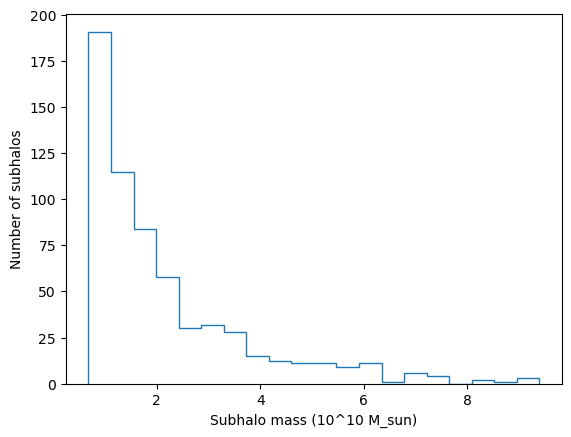

In [42]:
disk_ax_id = np.loadtxt("disk_ax.dat")
disk_circ_id = np.loadtxt("disk_circ.dat")
mass_cuts_id = np.loadtxt("mass_cuts.txt")[:,0]

common_id = list(set(disk_ax_id) & set(disk_circ_id) & set(mass_cuts_id))

index = []

for i in range(len(common_id)):
    ind = np.where(mass_cuts_id == common_id[i])
    index.append(ind)

mass_cuts_mass = []

for i in index:
    mass_cuts_mass.append(np.loadtxt("mass_cuts.txt")[:,1][i])
hist,bin_edges = np.histogram(mass_cuts_mass,bins=20)   

plt.ylabel("Number of subhalos")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.stairs(hist,bin_edges)
plt.show()

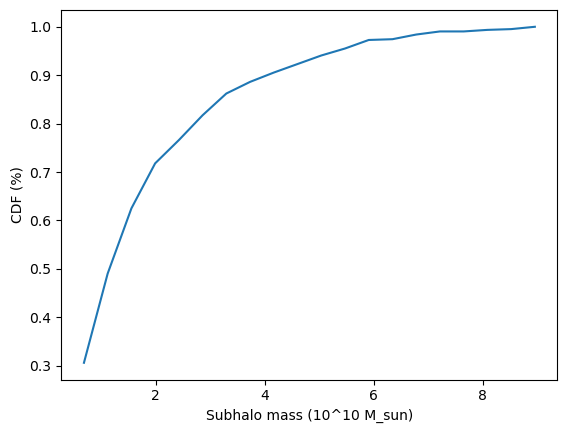

In [49]:
prob = hist/sum(hist)  
cumprob = np.cumsum(prob) 


plt.ylabel("CDF (%)")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.plot(bin_edges[:-1],cumprob)
plt.show()